<a href="https://colab.research.google.com/github/Ricardo428/Red-Convolutiva/blob/main/Modelo_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Modelo 3

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#Transformación

En la transformación he añadido una mayor variedad a las imagenes rotandolas e volteandolas horizaontalmente para evitar el overfiting

Como en el modelo 2 pero aumentando la rotación un poco

In [ ]:
# Importa las librerías necesarias de PyTorch
import torch
from torchvision import datasets,transforms
from torch.utils.data import DataLoader
from torch import nn,optim


#Relizamos la transformación para asegurar uniformidad en el conjunto
transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(30),                 # rotación aleatoria en ±10 grados
    transforms.ToTensor(),                         # convertir a tensor
    transforms.Normalize((0.5, 0.5, 0.5),          # normalización media y std por canal
                         (0.5, 0.5, 0.5))
])



ruta = '/content/drive/MyDrive/dataset'

# Cargamos el dataset
train_data = datasets.ImageFolder(root=ruta + "/train",transform = transform)
test_data = datasets.ImageFolder(root=ruta + "/test",transform = transform)
valid_data = datasets.ImageFolder(root=ruta + "/validation",transform = transform)


# Imprime los valores máximo y mínimo de un píxel en la primera imagen (después de la normalización)
# Obtenemos el valor máximo y mínimo, que están en el rango de [-1, 1]
print("Maximo valor de la imagen:",train_data[0][0].squeeze().max())
print("Minimo valor de la imagen:",train_data[0][0].squeeze().min())

# Informacion del dataset
print("\n--- Información del dataset ---")
print(f"Clases encontradas: {train_data.classes}")
print(f"Número de clases: {len(train_data.classes)}")
print(f"Num imagenes training: {len(train_data)}")
print(f"Num imagenes test: {len(test_data)}")
print(f"Num imagenes valid: {len(valid_data)}")

# Empaquetamos las imagenes en lotes de 32
train_loader = DataLoader(train_data,shuffle=True,batch_size=32)
test_loader = DataLoader(test_data,shuffle=False,batch_size=32)
valid_loader = DataLoader(valid_data,shuffle=False,batch_size=32)


Maximo valor de la imagen: tensor(1.)
Minimo valor de la imagen: tensor(-1.)

--- Información del dataset ---
Clases encontradas: ['bus', 'car', 'motorcycle', 'train', 'truck']
Número de clases: 5
Num imagenes training: 5418
Num imagenes test: 708
Num imagenes valid: 709


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class Vehiculos(nn.Module):
  def __init__(self):
    super(Vehiculos, self).__init__()

    # Tenemos 2 capas convolucionales para detectar patrones
    self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1)
    self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)

    # Una capa de MaxPooling para la reduccion de la imagen
    self.pool = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)

    # Apagado de la mitad de las neuronas evitando memorización
    self.dropout = nn.Dropout(0.5)

    self.fc1 = nn.Linear(64 * 48 * 48, 128)
    self.fc2 = nn.Linear(128, 5)

  def forward(self, x):

    # Aplicamos las capas convolucionales con su función de activación y un pooling
    x = self.conv1(x)
    x = F.relu(x)
    x = self.pool(x)

    x = self.conv2(x)
    x = F.relu(x)
    x = self.pool(x)

    # Aplanamos a un vector (1D) para las capas lineale
    x = x.view(-1, 64 * 48 * 48)

    # Aplicamos dropout antes de la primera capa fully-connected
    x = self.dropout(x)

    # Aplicamos las capas fully-connected
    x = self.fc1(x)
    x = F.relu(x)
    x = self.dropout(x)
    x = self.fc2(x)

    return x

In [ ]:
# Instanciación  de  la red
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f'Usando {device}')
net = Vehiculos().to(device)

# Definimos la función de perdida y el optimizador
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(),lr=0.0003)

Usando cuda


In [ ]:
import torch
import torch.nn.functional as F

def evaluate(model, loader, criterion, device):

    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)

            # Cálculo de la pérdida
            loss = criterion(outputs, labels)
            running_loss += loss.item()

            # Cálculo de aciertos
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    avg_loss = running_loss / len(loader)
    acc = 100.0 * correct / total if total > 0 else 0.0

    return avg_loss, acc

In [ ]:
# Entrenamiento de la red
num_epochs = 10

# Almacenamiento de resultados
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [],   'val_acc': [],
}

for epoch in range(num_epochs):
  epoch_loss = 0.0
  correct = 0
  total = 0

  net.train()
  for i, (images, labels) in enumerate(train_loader):
    images, labels = images.to(device), labels.to(device)

    # Cálculo de las salidas (forward)
    outputs = net(images)

    # Cálculo de la perdida
    loss = loss_fn(outputs, labels)

    # Cálculo de gradientes(backward)
    loss.backward()

    # Actualizar los pesos
    optimizer.step()

    # Reseteo de los gradientes
    optimizer.zero_grad()

    # Acumular la pérdida
    epoch_loss += loss.item()

    # Cálculo de aciertos en el entrenamiento
    _, predicted = torch.max(outputs, 1)
    correct += (predicted == labels).sum().item()
    total += labels.size(0)

  # Resultados del entrenamiento
  epoch_train_loss = epoch_loss / len(train_loader)
  epoch_train_acc = 100.0 * correct / total

  # Cálculo de aciertos y pérdida (Validation)
  epoch_val_loss, epoch_val_acc = evaluate(net, valid_loader, loss_fn, device)

  # Historial
  history['train_loss'].append(epoch_train_loss)
  history['train_acc'].append(epoch_train_acc)

  history['val_loss'].append(epoch_val_loss)
  history['val_acc'].append(epoch_val_acc)

  print(f"[Ep {epoch+1}] "
        f"Train loss: {epoch_train_loss:.3f} accuracy: {epoch_train_acc:.1f}% | "
        f"Val loss: {epoch_val_loss:.3f} accuracy: {epoch_val_acc:.1f}%")


[Ep 1] Train loss: 1.506 accuracy: 35.1% | Val loss: 1.303 accuracy: 50.1%
[Ep 2] Train loss: 1.281 accuracy: 49.2% | Val loss: 1.198 accuracy: 56.3%
[Ep 3] Train loss: 1.184 accuracy: 53.3% | Val loss: 1.163 accuracy: 56.3%
[Ep 4] Train loss: 1.137 accuracy: 55.6% | Val loss: 1.094 accuracy: 59.5%
[Ep 5] Train loss: 1.095 accuracy: 57.6% | Val loss: 1.066 accuracy: 59.5%
[Ep 6] Train loss: 1.047 accuracy: 59.8% | Val loss: 1.035 accuracy: 61.2%
[Ep 7] Train loss: 1.034 accuracy: 60.1% | Val loss: 1.018 accuracy: 61.8%
[Ep 8] Train loss: 1.007 accuracy: 60.9% | Val loss: 0.976 accuracy: 64.0%
[Ep 9] Train loss: 0.987 accuracy: 62.0% | Val loss: 0.946 accuracy: 67.0%
[Ep 10] Train loss: 0.959 accuracy: 63.4% | Val loss: 0.957 accuracy: 65.7%


In [ ]:
correct = 0
total = 0

net.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = net(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy of the model: {100 * correct / total}%')


Accuracy of the model: 65.3954802259887%


## Resultados
En el desarrollo de las épocas tenemos 2 metricas de cada conjunto (pérdida y precisión).Estas nos dejan ver el comportamiento de la red durante su entrenamineto.

Podemos observar que la red aprende pero lentamente este es el resultado de añadir transformaciones en el dataset y tener 2 capas convolucionales solamente, este modelo llega solamente a un 65 % el peor comparado con otros modelos

No se ve overfiting ya que el entrenamiento y la validación estan al mismo nivel(incluso la validación por encima) tanto en la precisión como en la pérdida y la précisión final del test esta al mismo nivel

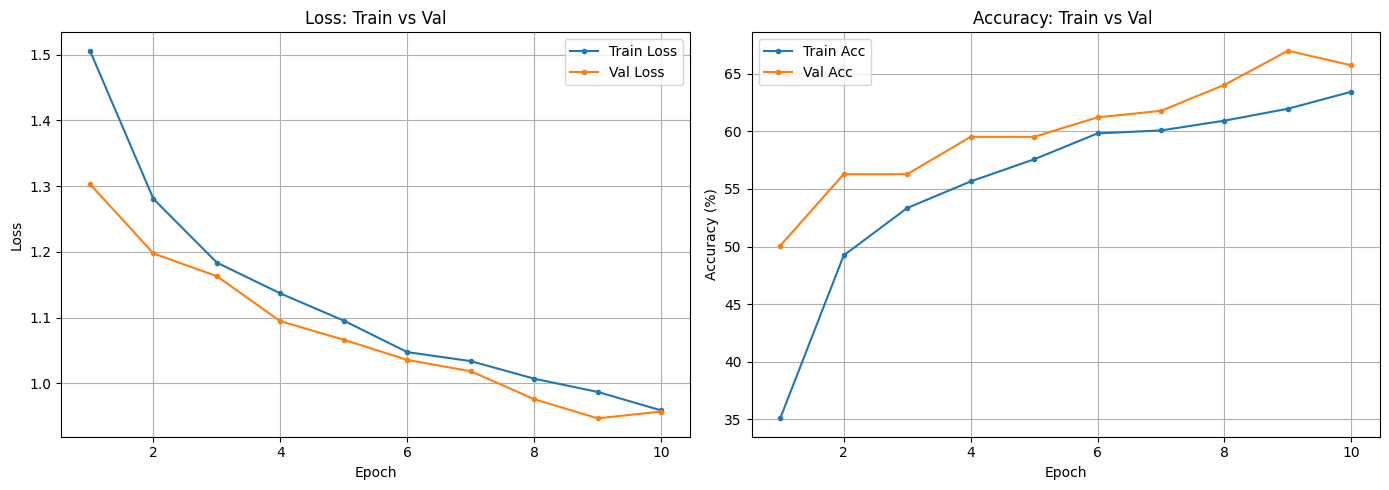

In [ ]:
import matplotlib.pyplot as plt


epochs = range(1, len(history['train_loss']) + 1)

plt.figure(figsize=(14, 5))

# Gráfico de pérdida
plt.subplot(1, 2, 1)
plt.plot(epochs, history['train_loss'], label='Train Loss', marker='.')
plt.plot(epochs, history['val_loss'],   label='Val Loss',   marker='.')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss: Train vs Val')
plt.legend()
plt.grid(True)

# Gráfico de precisión
plt.subplot(1, 2, 2)
plt.plot(epochs, history['train_acc'], label='Train Acc', marker='.')
plt.plot(epochs, history['val_acc'],   label='Val Acc',   marker='.')

plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy: Train vs Val ')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

#Graficas

En las gráficas podemos observar el historial de perdidas y preciciones

En la grafica de perdida se ve que la tendencia es disminuir los valores salvo en alguna época donde este sube

En la gráfica de precisión observamos que los porcentajes suben pero son un poco mas variables que las perdidas teniendo epocas seguidas donde sube y baja varias veces

##Matrices de confusión

A continuación vemos las matrices de confusión del entrenamiento, test  y validación que nos dejan   analizar con mayor detalle el comportamiento con cada una de las clases y asi ver que clase le cuesta más clasificar

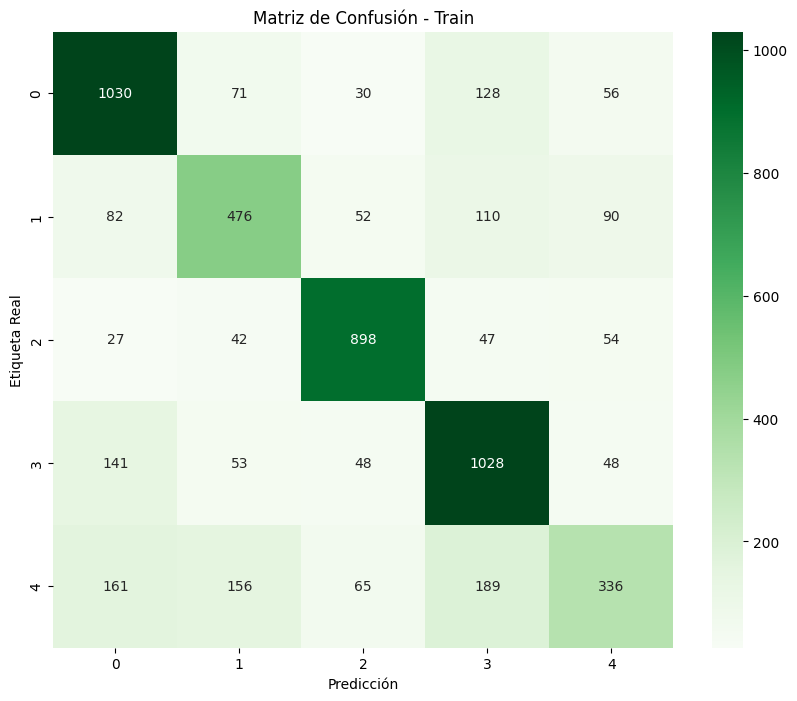

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

net.eval()

all_preds_test = []
all_labels_test = []

# Extracción de predicciones
with torch.no_grad():
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = net(images)
        _, predicted = torch.max(outputs.data, 1)
        all_preds_test.extend(predicted.cpu().numpy())
        all_labels_test.extend(labels.cpu().numpy())

# Comparación de las etiquetas reales con las predicciones
conf_matrix_test = confusion_matrix(all_labels_test, all_preds_test)

# Visualización de la matriz
plt.figure(figsize=(10,8))
sns.heatmap(conf_matrix_test, annot=True, fmt='d', cmap='Greens')
plt.title('Matriz de Confusión - Train')
plt.xlabel('Predicción')
plt.ylabel('Etiqueta Real')
plt.show()

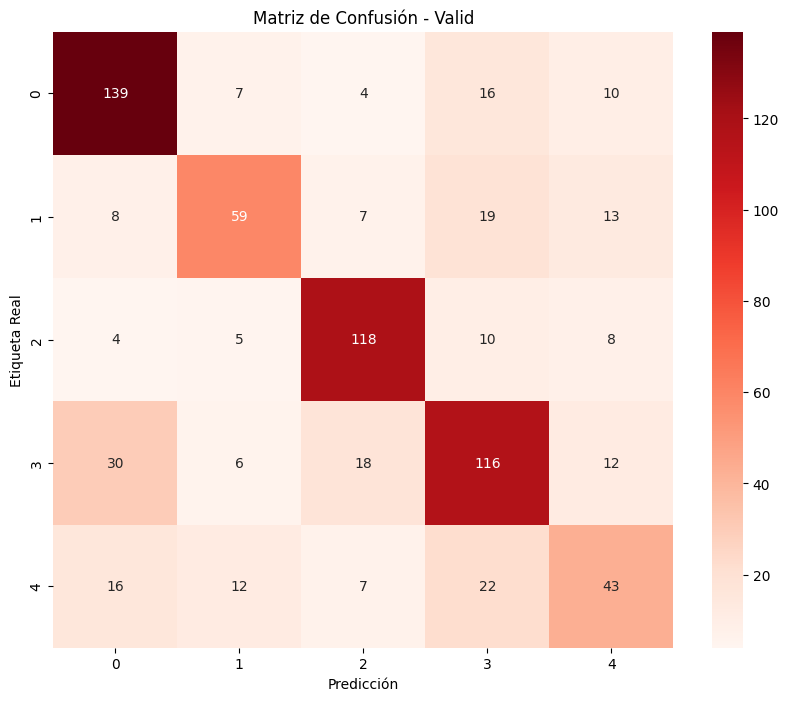

In [ ]:
net.eval()

all_preds_test = []
all_labels_test = []

# Extracción de predicciones
with torch.no_grad():
    for images, labels in valid_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = net(images)
        _, predicted = torch.max(outputs.data, 1)
        all_preds_test.extend(predicted.cpu().numpy())
        all_labels_test.extend(labels.cpu().numpy())

# Comparación de las etiquetas reales con las predicciones
conf_matrix_test = confusion_matrix(all_labels_test, all_preds_test)

# Visualización de la matriz
plt.figure(figsize=(10,8))
sns.heatmap(conf_matrix_test, annot=True, fmt='d', cmap='Reds')
plt.title('Matriz de Confusión - Valid')
plt.xlabel('Predicción')
plt.ylabel('Etiqueta Real')
plt.show()

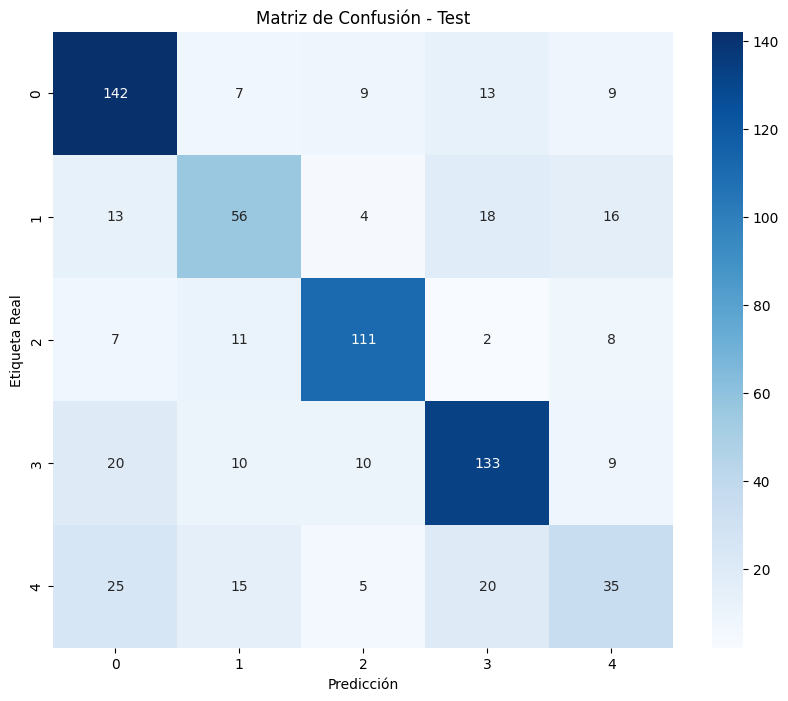

In [ ]:
net.eval()

all_preds_train = []
all_labels_train = []

# Extracción de predicciones
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = net(images)
        _, predicted = torch.max(outputs.data, 1)
        all_preds_train.extend(predicted.cpu().numpy())
        all_labels_train.extend(labels.cpu().numpy())

# Comparación de las etiquetas reales con las predicciones
conf_matrix_train = confusion_matrix(all_labels_train, all_preds_train)

# Visualización de la matriz
plt.figure(figsize=(10,8))
sns.heatmap(conf_matrix_train, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión - Test')
plt.xlabel('Predicción')
plt.ylabel('Etiqueta Real')
plt.show()

##Resultado de la visualización de las matrices de confusión

Las matrices de confusión revelan que el modelo tiene más dificultades con la segunda y quinta clase. Esto era predecible debido al desbalanceo del dataset: estas clases contaban con menos imagenes que el resto, lo que dificulta que la red aprenda a classificarlas correctamente